# Logistic Regression

In [148]:
import numpy as np
import pandas as pd


# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, FunctionTransformer, OrdinalEncoder
from category_encoders import WOEEncoder
from category_encoders.cat_boost import CatBoostEncoder



from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, check_cv
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef, average_precision_score

### Data Loading and Feature Splitting
This cell loads the dataset, separates the features (`X`) and target (`y`), and categorizes the columns into numeric and categorical types. It also displays the shape of the dataset.

In [149]:
df = pd.read_csv('/Users/lulin/Development/machine-learning/my-first-ml-project/data/raw/credit_risk_dataset.csv')

# Features / target
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

# Column splits
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
]

ordinal_cols = [
    "loan_grade",  # Ordinal: Grades have an inherent order (e.g., A > B > C)
    "cb_person_default_on_file",  
]
nominal_cols = [
    "person_home_ownership",  # Nominal: No inherent order
    "loan_intent",            # Nominal: No inherent order
]

X.shape, y.shape

((32581, 11), (32581,))

### Train test split

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((26064, 11), (6517, 11), (26064,), (6517,))

### Preprocessing Pipelines and Model Setup
Define the preprocessing pipelines for numeric and categorical features, combine them into a single preprocessor, and integrate the preprocessor with a Logistic Regression model in a complete pipeline.

In [151]:
# Outlier capping using IQR (caps each numeric column to [Q1-1.5*IQR, Q3+1.5*IQR])
def cap_iqr(X_array):
    X_array = np.asarray(X_array, dtype=float)
    capped = X_array.copy()
    for j in range(capped.shape[1]):
        col = capped[:, j]
        q1, q3 = np.nanpercentile(col, [25, 75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        capped[:, j] = np.clip(col, lower, upper)
    return capped

# ============ NUMERIC PIPELINE ============
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("cap", FunctionTransformer(cap_iqr, feature_names_out="one-to-one")),
    ("skew", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler()),
])

# ============ CATEGORICAL PIPELINE ============
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    #("woe", WOEEncoder()),
    ("cb", CatBoostEncoder())
])

# ============ COMBINE PIPELINES ============
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("nominal", nominal_pipeline, nominal_cols),
    ("ordinal", ordinal_pipeline, ordinal_cols),
])

# ============ FULL PIPELINE WITH MODEL ============
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")),
])

### Hyperparameter Tuning with GridSearchCV
This cell defines hyperparameter tuning for the Logistic Regression model using `GridSearchCV`. It defines a parameter grid, sets up a cross-validation strategy, and initializes the search process to find the best combination of hyperparameters.

In [185]:
C_values = [0.01, 0.1, 1, 10, 100]
penalties = ["l1", "l2"]  

param_dist = {
    "model__C": C_values,
    "model__penalty": penalties,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_dist,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [186]:
# Fit on TRAINING data only
grid_search.fit(X_train, y_train)

/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid thi

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [154]:
grid_search.cv_results_

{'mean_fit_time': array([1.24616604, 0.54702182, 1.94004488, 0.58958812, 4.31296949,
        0.59163833, 5.49192567, 0.70744133, 1.05543776, 0.66555138]),
 'std_fit_time': array([0.05841078, 0.03137524, 0.13014233, 0.07809016, 0.41874414,
        0.04740151, 1.13351996, 0.06286421, 0.03677887, 0.08236582]),
 'mean_score_time': array([0.05181727, 0.05924716, 0.06090703, 0.05912404, 0.07534218,
        0.05451803, 0.04113774, 0.07430162, 0.05930042, 0.0510726 ]),
 'std_score_time': array([0.00634642, 0.01001575, 0.01585489, 0.01067831, 0.0147432 ,
        0.00209857, 0.01382929, 0.02118911, 0.00237256, 0.0064423 ]),
 'param_model__C': masked_array(data=[0.01, 0.01, 0.1, 0.1, 1.0, 1.0, 10.0, 10.0, 100.0,
                    100.0],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=1e+20),
 'param_model__penalty': masked_array(data=['l1', 'l2', 'l1', 'l2', 'l1', 'l2', 'l1', 'l2', 'l1',
                    'l2']

In [187]:
grid_search.best_score_

0.6224300115232391

In [188]:
grid_search.best_params_

{'model__C': 100, 'model__penalty': 'l2'}

### Best Model Selection
This cell retrieves the best model identified during hyperparameter tuning using `GridSearchCV`. The best model is stored for further training and evaluation.

In [183]:
best_model = grid_search.best_estimator_

grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [184]:
# Train the best model on the entire training set
best_model.fit(X_train, y_train)

# Evaluate on TEST set
#y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
threshold = 0.75
y_pred = (y_prob >= threshold).astype(int)

# Calculate all metrics
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, average='weighted')
final_recall = recall_score(y_test, y_pred, average='weighted')
final_f1 = f1_score(y_test, y_pred, average='weighted')
final_mcc = matthews_corrcoef(y_test, y_pred)
final_roc_auc = roc_auc_score(y_test, y_prob)
final_pr_auc = average_precision_score(y_test, y_prob)

print("="*70)
print("FINAL TEST SET PERFORMANCE")
print("="*70)
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")
print(f"Matthews Correlation Coefficient: {final_mcc:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")
print(f"PR-AUC:    {final_pr_auc:.4f}")

FINAL TEST SET PERFORMANCE
Accuracy:  0.8337
Precision: 0.8421
Recall:    0.8337
F1-Score:  0.7970
Matthews Correlation Coefficient: 0.4339
ROC-AUC:   0.8679
PR-AUC:    0.7181


/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### GenericUnivariateSelect
This section uses `GenericUnivariateSelect` to analyze feature importance based on p-values. The method applies statistical tests to each feature and selects the most significant ones according to a specified threshold. The False Positive Rate (FPR) mode is used here, with a threshold of 0.05, to identify features that are statistically significant predictors of the target variable. The results include p-values and scores for each feature, which are sorted and displayed for further analysis.

In [159]:
from sklearn.feature_selection import GenericUnivariateSelect, f_classif

# Transform X_train using the preprocessor
X_train_transformed = preprocessor.fit_transform(X_train, y_train)

# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Perform feature selection using GenericUnivariateSelect
selector = GenericUnivariateSelect(score_func=f_classif, mode='fpr', param=0.05)
selector.fit(X_train_transformed, y_train)

# Get p-values and scores for each feature
feature_p_values = selector.pvalues_
feature_scores = selector.scores_

# Combine feature names with their p-values and scores
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'P-Value': feature_p_values,
    'Score': feature_scores
}).sort_values(by='P-Value')

# Format p-values to display in decimal notation
feature_importance['P-Value_'] = feature_importance['P-Value'].apply(lambda x: f"{x:.6f}")

print("Feature P-Values and Scores:")
print(feature_importance)

Feature P-Values and Scores:
                                    Feature        P-Value        Score  \
1                    numeric__person_income   0.000000e+00  2322.548387   
10      nominal__person_home_ownership_RENT   0.000000e+00  1617.056466   
17                               ordinal__0   0.000000e+00  5292.129876   
4                    numeric__loan_int_rate   0.000000e+00  2688.331526   
5              numeric__loan_percent_income   0.000000e+00  3281.867709   
7   nominal__person_home_ownership_MORTGAGE  4.975341e-211   979.122776   
18                               ordinal__1  3.789931e-180   832.127623   
9        nominal__person_home_ownership_OWN   3.754906e-63   282.911172   
2                numeric__person_emp_length   1.819648e-53   238.033948   
3                        numeric__loan_amnt   8.317405e-44   193.385633   
16             nominal__loan_intent_VENTURE   2.901368e-36   158.612054   
11   nominal__loan_intent_DEBTCONSOLIDATION   1.084726e-24   105.449852

### Feature Selection and Hyperparameter Optimization
This cell defines a pipeline that includes feature selection and hyperparameter optimization for the Logistic Regression model. It uses `GridSearchCV` to tune the number of selected features and model parameters, such as regularization strength, penalty type, and solver. The feature selection step evaluates features using statistical tests (`f_classif` and `mutual_info_classif`) to identify the most relevant predictors.

In [181]:
from sklearn.decomposition import NMF, PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Define the pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selector", "passthrough"),
    ("model", LogisticRegression(max_iter=1000)),
])

# Define the parameter grid
param_grid = [
    {
        "feature_selector": [SelectKBest(f_classif)],
        "feature_selector__k": [10, 12, 15, 17],  # Number of features to select
        "model__C": [0.01, 0.1, 1, 10, 100],  # Regularization strength
        "model__penalty": ["l1", "l2"],  # Penalty type
        "model__solver": ["lbfgs", "liblinear"]
    },
    {
        "feature_selector": [SelectKBest(mutual_info_classif)],
        "feature_selector__k": [10, 12, 15, 17],  # Number of features to select
        "model__C": [0.01, 0.1, 1, 10, 100],  # Regularization strength
        "model__penalty": ["l1", "l2"],  # Penalty type
        "model__solver": ["lbfgs", "liblinear"]
    },
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="f1",  # Use F1 score as the evaluation metric
    n_jobs=-1,  # Use all available cores
    verbose=1,
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'feature_selector': [SelectKBest()], 'feature_selector__k': [10, 12, ...], 'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], ...}, {'feature_selector': [SelectKBest(s... 0x146c4bba0>)], 'feature_selector__k': [10, 12, ...], 'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defau

In [182]:
# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid thi

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'feature_selector': [SelectKBest()], 'feature_selector__k': [10, 12, ...], 'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], ...}, {'feature_selector': [SelectKBest(s... 0x146c4bba0>)], 'feature_selector__k': [10, 12, ...], 'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defau

In [163]:
grid_search.cv_results_

{'mean_fit_time': array([ 0.4419652 ,  0.80983901,  0.56528993,  0.58570828,  0.53582025,
         1.3970664 ,  0.65441847,  0.64938302,  0.54028244,  1.93700819,
         0.62112083,  0.63761454,  0.54249139,  2.25909691,  0.69354725,
         0.71573162,  0.48457398,  1.95134997,  0.57219691,  0.59963374,
         3.76230192,  4.50449162,  4.79915662,  5.7883954 ,  5.72429099,
         6.42426319,  5.92690821,  6.45991478,  5.71527081,  7.32206411,
         6.334901  ,  6.43261585,  6.19476681,  8.16882858,  6.54899316,
         6.53969178,  6.05153599,  8.85452132,  8.13631725,  6.72017531,
         0.75025301,  1.4530652 ,  0.87190976,  1.12568521,  0.79517617,
         2.54882321,  1.1251802 ,  0.9492588 ,  0.75853124,  3.54910221,
         1.03602495,  1.18627791,  0.82410541,  3.75848737,  1.08978038,
         1.02854776,  0.94573264,  4.12860279,  1.23211741,  1.26984324,
         6.15330524,  6.46325498,  5.8306972 ,  5.27533064,  5.19761958,
         7.07524681,  5.43594308, 

In [167]:
grid_search.best_params_

{'feature_selector': SelectKBest(),
 'feature_selector__k': 17,
 'feature_selector__score_func': <function sklearn.feature_selection._mutual_info.mutual_info_classif(X, y, *, discrete_features='auto', n_neighbors=3, copy=True, random_state=None, n_jobs=None)>,
 'model__C': 100,
 'model__penalty': 'l2',
 'model__solver': 'lbfgs'}

In [168]:
grid_search.best_score_

0.6227359507399746

### Best Model Selection
This cell retrieves the best model identified during hyperparameter tuning using `GridSearchCV`. The best model is stored for further training and evaluation.

In [171]:
best_model = grid_search.best_estimator_

grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [175]:
# Train the best model on the entire training set
best_model.fit(X_train, y_train)

/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [176]:
# Evaluate on TEST set
#y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
threshold = 0.75
y_pred = (y_prob >= threshold).astype(int)

# Calculate all metrics
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, average='weighted')
final_recall = recall_score(y_test, y_pred, average='weighted')
final_f1 = f1_score(y_test, y_pred, average='weighted')
final_mcc = matthews_corrcoef(y_test, y_pred)
final_roc_auc = roc_auc_score(y_test, y_prob)
final_pr_auc = average_precision_score(y_test, y_prob)

print("="*70)
print("FINAL TEST SET PERFORMANCE")
print("="*70)
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")
print(f"Matthews Correlation Coefficient: {final_mcc:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")
print(f"PR-AUC:    {final_pr_auc:.4f}")

FINAL TEST SET PERFORMANCE
Accuracy:  0.8335
Precision: 0.8419
Recall:    0.8335
F1-Score:  0.7967
Matthews Correlation Coefficient: 0.4332
ROC-AUC:   0.8679
PR-AUC:    0.7180


### Model Evaluation and Visualization
This cell evaluates the trained model on the test set. It generates a confusion matrix, ROC curve, and precision-recall curve, and displays a detailed classification report to summarize the model's performance.

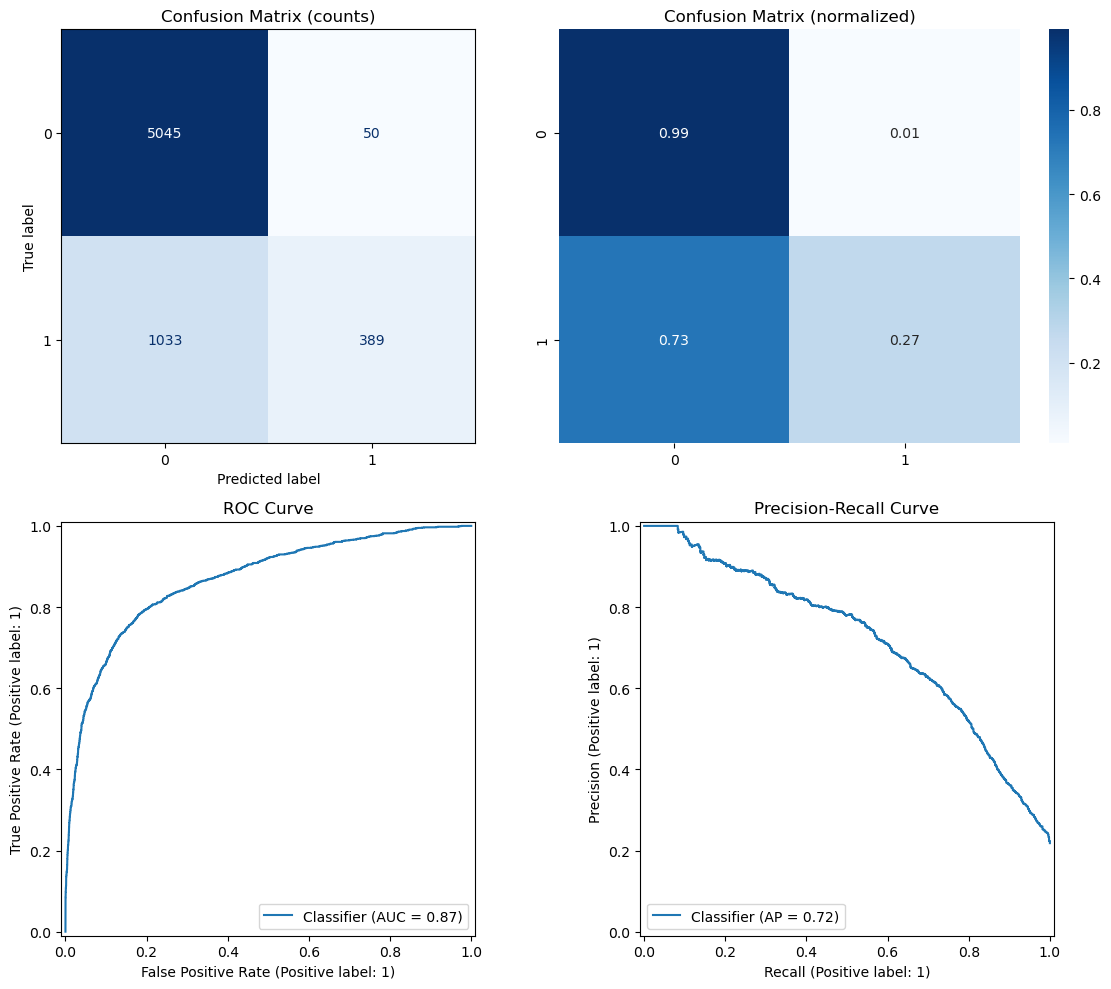


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

Approved (0)       0.83      0.99      0.90      5095
  Denied (1)       0.89      0.27      0.42      1422

    accuracy                           0.83      6517
   macro avg       0.86      0.63      0.66      6517
weighted avg       0.84      0.83      0.80      6517



In [166]:
# Confusion Matrix and additional visualizations
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Confusion matrix (counts)
ConfusionMatrixDisplay(cm).plot(ax=axes[0, 0], cmap="Blues", colorbar=False)
axes[0, 0].set_title("Confusion Matrix (counts)")

# Confusion matrix (normalized)
cmn = confusion_matrix(y_test, y_pred, normalize="true")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", ax=axes[0, 1])
axes[0, 1].set_title("Confusion Matrix (normalized)")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1, 0])
axes[1, 0].set_title("ROC Curve")

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1, 1])
axes[1, 1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=["Approved (0)", "Denied (1)"]))

/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lulin/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid thi

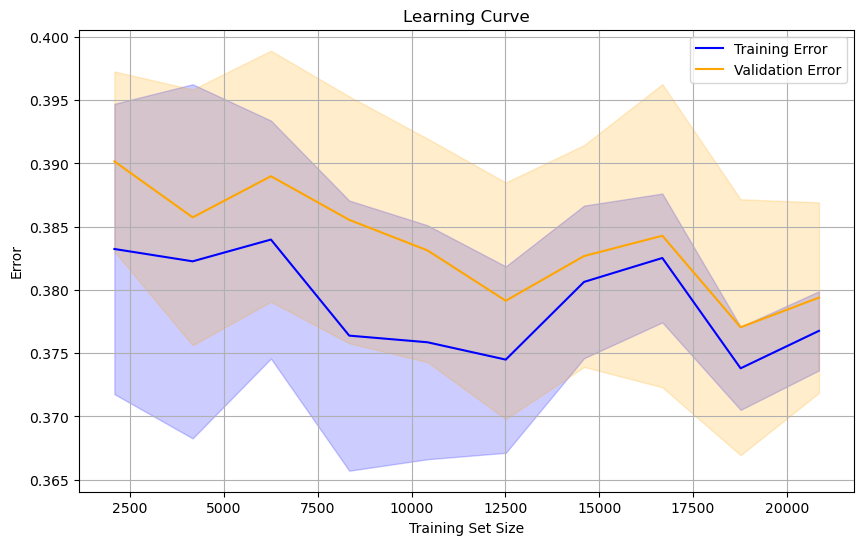

In [172]:
# Plot learning curve: training and validation errors
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
)

# Calculate mean and standard deviation for training and validation errors
train_error = 1 - np.mean(train_scores, axis=1)
train_std = np.std(1 - train_scores, axis=1)
val_error = 1 - np.mean(val_scores, axis=1)
val_std = np.std(1 - val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_error, label="Training Error", color="blue")
plt.fill_between(train_sizes, train_error - train_std, train_error + train_std, color="blue", alpha=0.2)
plt.plot(train_sizes, val_error, label="Validation Error", color="orange")
plt.fill_between(train_sizes, val_error - val_std, val_error + val_std, color="orange", alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Error")
plt.legend(loc="best")
plt.grid()
plt.show()